<a href="https://colab.research.google.com/github/Basurero2/Data-Science-probando-relaciones-con-regresion-lineal/blob/juan-carlos/precios_de_inmuebles_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Precificación inmobiliaria**

**Objetivo**: Estimar los precios de los inmuebles.
 * Identificar los aspectos que tienen más influencia en la precificación de los inmuebles.
 * Entender cuál de todos estos aspectos es el más relevante.
 * Precificar un inmueble nuevo.

Base de datos simplificada e inspirada en [House Prices](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)



![](https://i.imgur.com/A8X79yq.jpeg)


# 1. Ajustando una recta

## Conociendo los datos

**Diccionario**:
- area_primer_piso: Se refiere al área del primer piso de la propiedad, medida en metros cuadrados.
- existe_segundo_piso: Esta variable es binaria, indicando si la propiedad tiene o no un segundo piso. Puede ser representada como 1 para "sí" y 0 para "no".
- area_segundo_piso: Si la propiedad tiene un segundo piso, esta variable representa el área total del segundo piso, medida en metros cuadrados.
- cantidad_baños: Indica el número total de baños en la propiedad.
- capacidad_coches_garaje: Esta variable indica la capacidad del garaje de la propiedad, es decir, el número máximo de coches que pueden estacionarse en el garaje.
- calidad_de_la_cocina_Excelente: Esta es una variable categórica que evalúa la calidad de la cocina en la propiedad. En este caso, se asume que si la cocina es considerada "Excelente" se representa por 1, y de lo contrario, por 0.
- precio_de_venta: Este es el precio de venta de la propiedad en reales. Es la variable objetivo que se intenta predecir utilizando los otros atributos de la propiedad.

In [52]:
import pandas as pd


In [53]:
#Leyendo los datos
datos = pd.read_csv("/content/precios_casas.csv")
datos.head()


,Id,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente,precio_de_venta
0,1,79.5224,1,79.3366,2,548,0,1027905.0
1,2,117.2398,0,0.0000,2,460,0,894795.0
2,3,85.4680,1,80.4514,2,608,0,1101855.0
3,4,89.2769,1,70.2324,1,642,0,690200.0
4,5,106.3705,1,97.8237,2,836,0,1232500.0


In [54]:
#Cuáles factores fueron colectados
datos.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Id                           1438 non-null   int64  
 1   area_primer_piso             1438 non-null   float64
 2   tiene_segundo_piso           1438 non-null   int64  
 3   area_segundo_piso            1438 non-null   float64
 4   cantidad_banos               1438 non-null   int64  
 5   capacidad_carros_garage      1438 non-null   int64  
 6   calidad_de_cocina_excelente  1438 non-null   int64  
 7   precio_de_venta              1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [55]:
datos = datos.drop(columns=["Id"])  #elminamos columna Id yaque es lo mismo que el indice

In [56]:
datos.head()

,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente,precio_de_venta
0,79.5224,1,79.3366,2,548,0,1027905.0
1,117.2398,0,0.0000,2,460,0,894795.0
2,85.4680,1,80.4514,2,608,0,1101855.0
3,89.2769,1,70.2324,1,642,0,690200.0
4,106.3705,1,97.8237,2,836,0,1232500.0


## Correlación

**¿Cuáles factores están relacionados con el precio de la casa? ¿Cómo es esa relación?**

El coeficiente de correlación de Pearson nos permite medir la relación lineal entre variables, ofreciendo una escala que varía de -1 a 1, la cual interpretamos según su intensidad y dirección:

* **-1**: correlación negativa perfecta: a medida que una variable aumenta, la otra disminuye.  
* **0**: no hay relación lineal entre las variables.  
* **1**: correlación positiva perfecta: a medida que una variable aumenta, la otra también aumenta.  



In [100]:
# Correlación
corr = datos.corr()
corr
#DataFrame de dimensiones n x n (n : variables), muestra correlaciones
# -1 a 0, correlacion inversa
# 0 a 1, correlacion directa
# mientras mas cerca este a los extremos el tipo de correlacion es mas fuerte


,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente,precio_de_venta
area_primer_piso,1.000000,-0.376805,-0.253793,0.369368,0.481231,0.323496,0.616557
tiene_segundo_piso,-0.376805,1.000000,0.917101,0.292780,-0.001284,-0.020045,0.138541
area_segundo_piso,-0.253793,0.917101,1.000000,0.412777,0.131938,0.025248,0.305311
cantidad_banos,0.369368,0.292780,0.412777,1.000000,0.409281,0.154102,0.563132
capacidad_carros_garage,0.481231,-0.001284,0.131938,0.409281,1.000000,0.276759,0.640214
calidad_de_cocina_excelente,0.323496,-0.020045,0.025248,0.154102,0.276759,1.000000,0.496223
precio_de_venta,0.616557,0.138541,0.305311,0.563132,0.640214,0.496223,1.000000


In [101]:
corr["precio_de_venta"]  #obtenemos las correlaciones de la variable "precio_de_venta", Serie

,precio_de_venta
area_primer_piso,0.616557
tiene_segundo_piso,0.138541
area_segundo_piso,0.305311
cantidad_banos,0.563132
capacidad_carros_garage,0.640214
calidad_de_cocina_excelente,0.496223
precio_de_venta,1.000000


In [105]:
corr["area_primer_piso"]

,area_primer_piso
area_primer_piso,1.000000
tiene_segundo_piso,-0.376805
area_segundo_piso,-0.253793
cantidad_banos,0.369368
capacidad_carros_garage,0.481231
calidad_de_cocina_excelente,0.323496
precio_de_venta,0.616557


In [103]:
# Actividad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Grafico de calor triangular
- es triangular por la relacion A x B es lo mismo que B x A, entonces hay una simetria, por eso solo se muestra una mitad
- Para ver todas las relaciones, busca tanto en grafica el eje y, eje x,
las variables se repiten

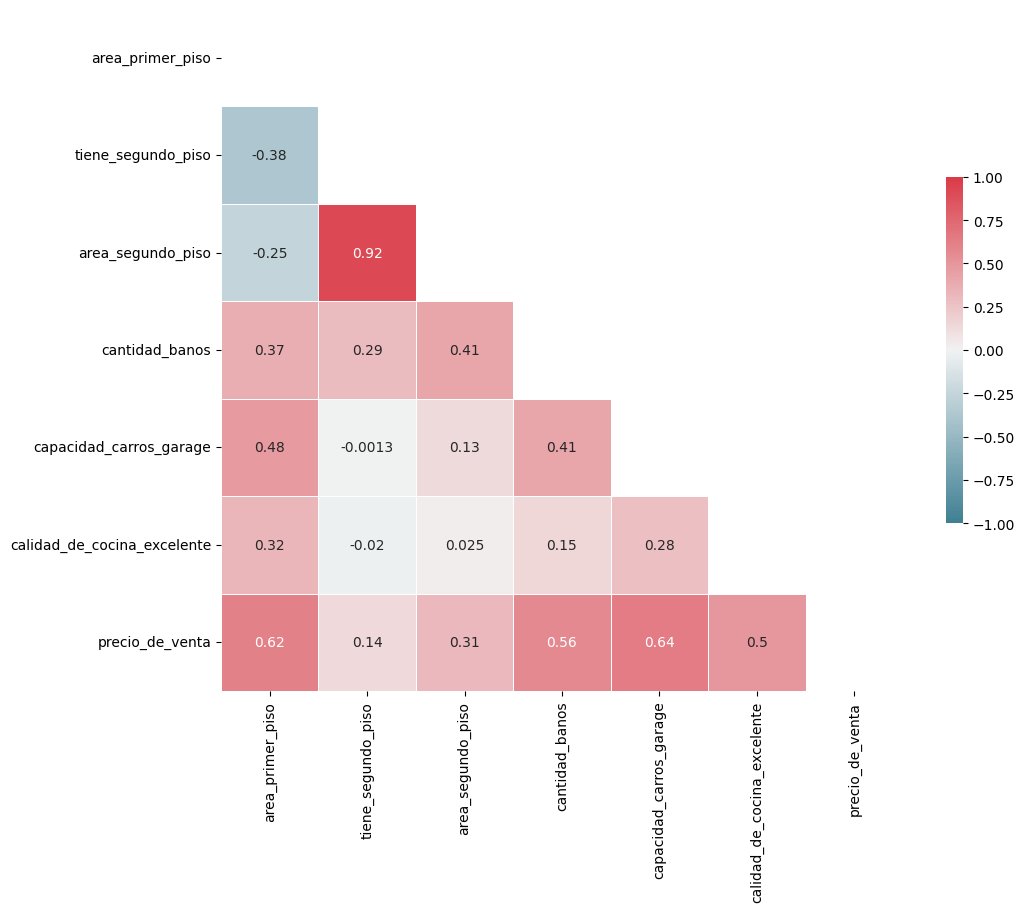

In [104]:


# ¿Qué factores están más correlacionados?

# Generar una máscara para el triángulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar la figura de matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Generar el mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

# Mostrar el mapa de calor (heatmap)
plt.show()

## Relacionando variables

In [121]:
# importando los paquetes para la visualización}
import matplotlib.pyplot as plt
import plotly.express as px


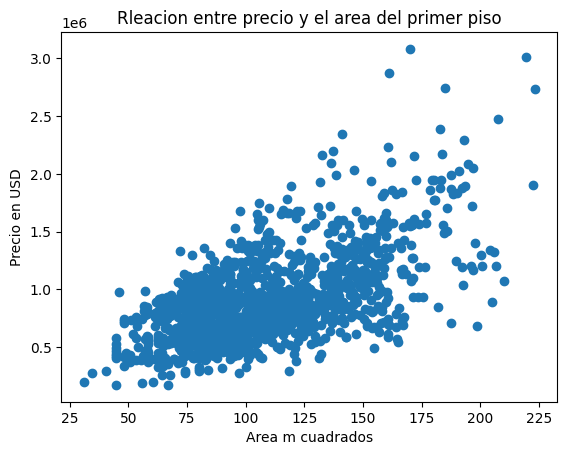

In [110]:
# Cómo se relacionan el área construída y el precio del inmueble?
plt.scatter(datos["area_primer_piso"], datos["precio_de_venta"])
plt.title("Relacion entre precio y el area del primer piso")
plt.xlabel("Area m cuadrados")
plt.ylabel("Precio en USD")
plt.show()



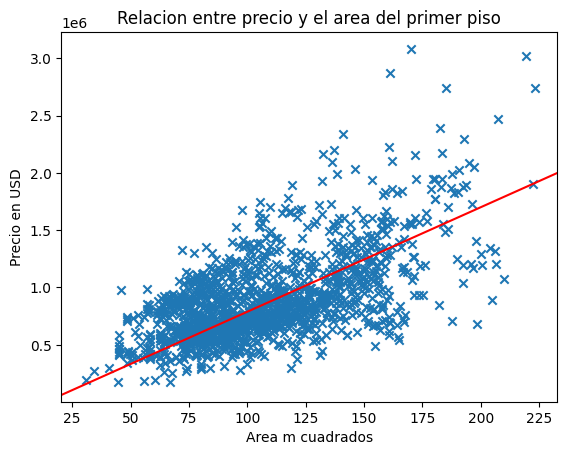

In [119]:
# Aparentemente mientras mayor es el área del primer piso, mayor es el precio de la casa.
# E si quisieramos trazar una línea que nos permita describir este comportamiento?
plt.scatter(datos["area_primer_piso"], datos["precio_de_venta"], marker="x")
plt.title("Relacion entre precio y el area del primer piso")
plt.xlabel("Area m cuadrados")
plt.ylabel("Precio en USD")

plt.axline(xy1=(30, 150000), xy2=(200, 1700000), color="r")

plt.show()


## Mejor recta

¿Qué es OLS?:

- OLS significa Ordinary Least Squares (en español: Mínimos Cuadrados Ordinarios).

- ¿Qué significa?: Es el método estándar para la Regresión Lineal.

- ¿Qué hace?: Su "misión" es dibujar una línea recta de tal forma que la distancia al cuadrado entre esa línea y todos tus puntos azules sea la mínima posible.

- En resumen: Es la línea que mejor representa la tendencia general. Si la línea sube, la relación es positiva; si baja, es negativa.

Esta recta no es solo un adorno; tiene un poder predictivo:
- Predicción: Si tienes una casa nueva que mide 150 $m^2$, solo tienes que buscar el 150 en el eje X, subir hasta chocar con la línea roja, y ver qué precio marca el eje Y. Esa sería tu estimación basada en los datos.

- Validación: Si la línea está muy cerca de la mayoría de los puntos, tu modelo es muy confiable. Si los puntos están muy dispersos y lejos de la línea roja, la relación es débil.

$$y = mx + b$$
- $y$ (Precio): Lo que queremos predecir.
- $x$ (Área): La variable que conocemos.
- $m$ (Pendiente): Cuánto sube el precio por cada metro cuadrado adicional.
- $b$ (Intercepto): El valor teórico del precio si el área fuera cero.

In [127]:
# Cuál es la recta que mejor se ajusta a esta relación
px.scatter(datos, x="area_primer_piso", y="precio_de_venta", trendline="ols", trendline_color_override="red")
#trendline = "ols" : linea regresion lineal, indica el comportamiento de nuestros datos
#OLS : Ordinary Least Squares (en español: Mínimos Cuadrados Ordinarios).


# 2. Explicando la recta
Ajustamos una recta entre los $m^2$ del primer piso y el precio de la casa. Queremos explicar el precio de la casa a partir de su tamaño, por eso decimos que:

* Variable explicativa/independiente: Área del primer piso  
* Variable de respuesta/dependiente: Precio de la casa  

In [63]:
#Quién es nuestra variable de respuesta?


### Separando datos para entrenamiento y para prueba

El conjunto de **entrenamiento** se utiliza para ajustar el modelo, mientras que el conjunto de **prueba** se usa para evaluar su desempeño al predecir precios de viviendas no vistos durante el entrenamiento, lo que ayuda a la generalización del modelo.

In [64]:
# import train_test_split


In [65]:
#Datos de entrenamiento para usar la fórmula


In [66]:
# import ols


In [67]:
# ajustando el primer modelo


## Analizando los coeficientes

(intensidad, dirección y significancia)




In [68]:
# visualizando los parámetros


In [69]:
# El resumen del modelo


- El **punto de intercepción** es el valor esperado del precio de la casa cuando todas las demás variables son cero. En este caso, cuando todas las demás variables, incluida el área del primer piso, son cero, el precio esperado de la casa es de $145.196,40. No siempre se tiene una interpretación práctica para este número.

- El **efecto individual** del área es de \$6.833,97. Esto indica que por cada metro cuadrado adicional al área del primer piso, se espera que el precio de la casa aumente en promedio \$6.833,97.

<img src="https://i.ibb.co/CJwfMgW/coeficientes.png" alt="coeficientes" border="0">


## Explicabilidad del modelo

**¿En qué medida la variación del área explica los diversos precios de las casas?**  

En este caso, recurrimos a la métrica R², el coeficiente de determinación. El R² varía de 0 a 1, donde 1 indica un ajuste perfecto del modelo a los datos, es decir, todas las variaciones en la variable dependiente son explicadas por las variables independientes en el modelo. Por otro lado, un R² de 0 indica que el modelo no explica ninguna variabilidad en la variable dependiente.

In [70]:
# observando el R²


## Entendiendo el resíduo

In [71]:
# Quiénes son los residuos?


In [72]:
# Cómo están distribuidos


<img src="https://i.ibb.co/zGTB35V/residuos.png" alt="residuos" border="0">

## Obteniendo el R² de la previsión

In [73]:
# definiendo la 'Y' prevista


In [74]:
# importando el r2_score


In [75]:
# mostrando el resultado de r²


# 3. Añadiendo otras características

El modelo con un solo factor nos mostró un R² de 0.38, es decir, aproximadamente el 38% de la variación observada en los precios de las casas puede explicarse por la variación en el área.  
Esto indica que aún existe una cantidad significativa de variación que no está siendo capturada por este modelo específico. Analizaremos otros factores para explicar el precio de las casas.

## Analizando los factores

In [76]:
# cuáles otras características podrían explicar el precio de los inmuebles?


In [77]:
#Vamos a analizar solamente y_vars='precio_de_venta'


## Añadiendo factores al modelo

In [78]:
# importando la api de statsmodels


In [79]:
# Añadiendo una constante


In [80]:
# Creando el modelo de regresión (con todas las variables): saturado


In [81]:
# Modelo sin el área del segundo piso


In [82]:
# Modelo sin la información del garage
# Modelo sin el área del segundo piso


In [83]:
# Resumen del modelos


## Comparando los modelos
Cuál es el modelo?


In [84]:
# Cuántos parámetros tiene el modelo?


# 4. Precificando las casas

## Obteniendo el R² de la previsión

In [85]:
# Añadiendo una constante en X_test


In [86]:
# Previsión con el modelo 3


In [87]:
# Cuál es el r² de la previsión?


In [88]:
# Cuál es el R² del entrenamiento?


## Precificando una casa

<img src="https://i.ibb.co/SvG4V4j/costo.png" alt="costo" border="0">

In [89]:
#Nuevo inmueble


In [90]:
# Cuál es el precio del inmueble de acuerdo con el modelo 0?


In [91]:
#Cuál es el precio del inmueble de acuerdo con el modelo 3?


## Precificando varias casas

<img src="https://i.imgur.com/i0skFlB.jpeg" width="600"/>

In [92]:
# Leyendo varias casas?


In [93]:
# Añadiendo una constante


In [94]:
# Cuál es el precio de estas nuevas casas?
# precio_casas = pd.DataFrame()


# 5. Investigando el modelo





## Multicolinearidad

Cuando dos o más cosas que estás intentando estudiar son tan parecidas que es difícil determinar cuánto está influyendo cada una de ellas en el resultado.

In [95]:
# importar el VIF de statsmodel


In [96]:
# VIF 1


In [97]:
# VIF 3


## Análisis de los residuos

Residuos: la discrepancia entre los valores reales y los valores que el modelo predice para los mismos puntos de datos.

<img src="https://i.ibb.co/9bmySbm/heterocedasticidad.png" alt="heterocedasticidad" border="0">